## Knowledge Discovery in Databases (KDD) Framework

This notebook follows the KDD process, which involves these main steps:
1. **Data Selection & Preparation**: Identifying relevant data, cleaning, and formatting it.
2. **Data Preprocessing**: Handling outliers, transformations, and feature engineering.
3. **Data Mining**: Applying various algorithms for pattern discovery (e.g., classification, regression, clustering).
4. **Evaluation**: Assessing the discovered patterns and models.

Import Library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC, SVR

from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    mean_squared_error,
    silhouette_score
)

from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings("ignore")

print("Semua library berhasil di-import!")

Semua library berhasil di-import!


1. Data Selection

melakukan seleksi

In [2]:
print("--- 1. DATA SELECTION ---")
# Membaca dataset
df = pd.read_csv('andini.csv')

# Memilih fitur numerik yang relevan untuk clustering
selected_columns = ['studytime', 'freetime', 'absences', 'G1', 'G2', 'G3']
df_selected = df[selected_columns]

print(f"Dataset awal diload. Memilih kolom: {selected_columns}")
# Perbaikan ada di baris bawah ini (menambahkan tanda kutip dan kurung tutup)
print(f"Dimensi data saat ini: {df_selected.shape[0]} baris, {df_selected.shape[1]} kolom.\n")

--- 1. DATA SELECTION ---
Dataset awal diload. Memilih kolom: ['studytime', 'freetime', 'absences', 'G1', 'G2', 'G3']
Dimensi data saat ini: 395 baris, 6 kolom.



2. Data Cleaning

In [3]:
print("--- 2. DATA CLEANING ---")
# Mengisi nilai kosong (jika ada) dengan rata-rata
df_clean = df_selected.fillna(df_selected.mean())

# Mengecek dan menghapus duplikat
duplicates = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"Ditemukan dan dihapus {duplicates} data duplikat.")
print(f"Dimensi data setelah dibersihkan: {df_clean.shape[0]} baris.\n")

--- 2. DATA CLEANING ---
Ditemukan dan dihapus 9 data duplikat.
Dimensi data setelah dibersihkan: 386 baris.



3. Data Transformation

In [4]:
# ==========================================
# TAHAP 3: DATA TRANSFORMATION
# ==========================================
print("--- PROSES DATA TRANSFORMATION ---")

# 1. Transformasi Data Teks Menjadi Angka (Label Encoding)
# Loop ini akan mengecek semua kolom, kalau isinya teks (object), akan diubah jadi angka
encoder = LabelEncoder()
for kolom in df.columns:
    if df[kolom].dtype == 'object': 
        df[kolom] = encoder.fit_transform(df[kolom])

# Update fitur (Di sini kita tetap pakai 5 fitur awal agar grafik selanjutnya tetap stabil)
# Tapi karena semua data sudah jadi angka, kamu sebenarnya bisa pakai fitur lain juga
features = ['studytime', 'failures', 'absences', 'G1', 'G2']
X = df[features]

# 2. Target Klasifikasi (1 = Lulus, 0 = Gagal)
y_class = df['G3'].apply(lambda x: 1 if x >= 10 else 0) 

# 3. Target Regresi (Nilai G3 asli untuk SVR)
y_reg = df['G3'] 

# 4. Pecah data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)
_, _, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print("Tahap Transformation Selesai! Semua data teks sudah diubah menjadi angka.")

print("\n--- 3. DATA TRANSFORMATION ---")
# Karena algoritma clustering (K-Means & Hierarchical) berbasis 'Jarak / Distance',
# kita WAJIB melakukan standarisasi (Scaling) agar rentang nilainya sama.
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_clean)

# Jadikan dataframe lagi agar mudah dibaca
df_scaled = pd.DataFrame(data_scaled, columns=df_clean.columns)
display(df_scaled.head())

--- PROSES DATA TRANSFORMATION ---
Tahap Transformation Selesai! Semua data teks sudah diubah menjadi angka.

--- 3. DATA TRANSFORMATION ---


,studytime,freetime,absences,G1,G2,G3
0,-0.043247,-0.231660,0.026058,-1.786266,-1.258294,-1.001921
1,-0.043247,-0.231660,-0.222299,-1.786266,-1.523560,-1.001921
2,-0.043247,-0.231660,0.522772,-1.185134,-0.727763,-0.112349
3,1.149134,-1.225226,-0.470655,1.219395,0.863832,0.999617
4,-0.043247,-0.231660,-0.222299,-1.485700,-0.197231,-0.112349


4. Data Mining
Proses melatih ke-4 algoritma (Naive Bayes, Decision Tree, SVM, dan SVR, K-Means, Hierarchical).

In [5]:
# Latih semua modelnya
nb_model = GaussianNB().fit(X_train, y_train)
dt_model = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)
svm_model = SVC(kernel='linear').fit(X_train, y_train)
svr_model = SVR(kernel='rbf').fit(X_train, y_train_reg)

print("Tahap Data Mining Selesai! Model sudah pintar.")

Tahap Data Mining Selesai! Model sudah pintar.


Naive bayes

Naive Bayes adalah algoritma klasifikasi yang menggunakan Teorema Bayes untuk memprediksi kelas suatu data berdasarkan nilai probabilitas. Algoritma ini mengasumsikan bahwa setiap fitur bersifat independen satu sama lain.

=== NAIVE BAYES ===
Accuracy: 0.8607594936708861
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        27
           1       0.90      0.88      0.89        52

    accuracy                           0.86        79
   macro avg       0.84      0.85      0.85        79
weighted avg       0.86      0.86      0.86        79



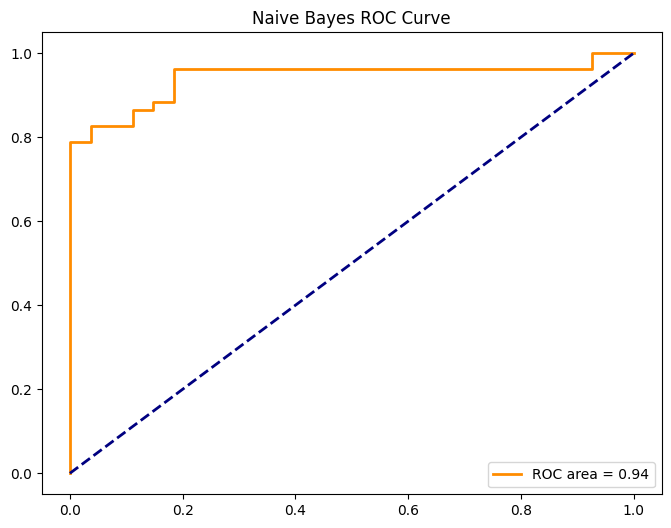

In [6]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

# Output Teks (Akurasi & Report)
print("=== NAIVE BAYES ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

# 1. Visualisasi Kurva ROC (Pengganti Diagram Pohon)
y_prob_nb = nb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC area = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Naive Bayes ROC Curve")
plt.legend(loc="lower right")
plt.show()

Berdasarkan hasil diatas, model yang menggunakan Naive Bayes memperoleh akurasi sebesar 86,08%, yang berarti ada sekitar 86% data uji berhasil diklasifikasikan dengan benar oleh model. Selain itu ada juga model memperoleh nilai AUC (Area Under Curve) sebesar 0,94 pada ROC Curve, yang menunjukkan kemampuan yang sangat baik dalam membedakan antara kelas 0 dan kelas 1 dapat dilihat kurva ROC yang berada jauh di atas garis diagonal atau bisa disebut prediksi acak dan mendekati sudut kiri atas grafik. Dengan secara keseluruhan, hasil tersebut menunjukkan bahwa model dari Naive Bayes memiliki performa cukup baik.

Decision tree

Decision Tree (DT) adalah algoritma klasifikasi yang bekerja dengan membentuk struktur pohon keputusan untuk mengelompokkan data berdasarkan aturan tertentu. Setiap cabang pada pohon mewakili keputusan berdasarkan nilai suatu fitur, sedangkan daun (leaf) menunjukkan hasil klasifikasi. Decision Tree mudah dipahami dan digunakan karena proses pengambilan keputusannya dapat divisualisasikan dalam bentuk pohon.

Accuracy: 0.8987341772151899
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        27
           1       0.92      0.92      0.92        52

    accuracy                           0.90        79
   macro avg       0.89      0.89      0.89        79
weighted avg       0.90      0.90      0.90        79



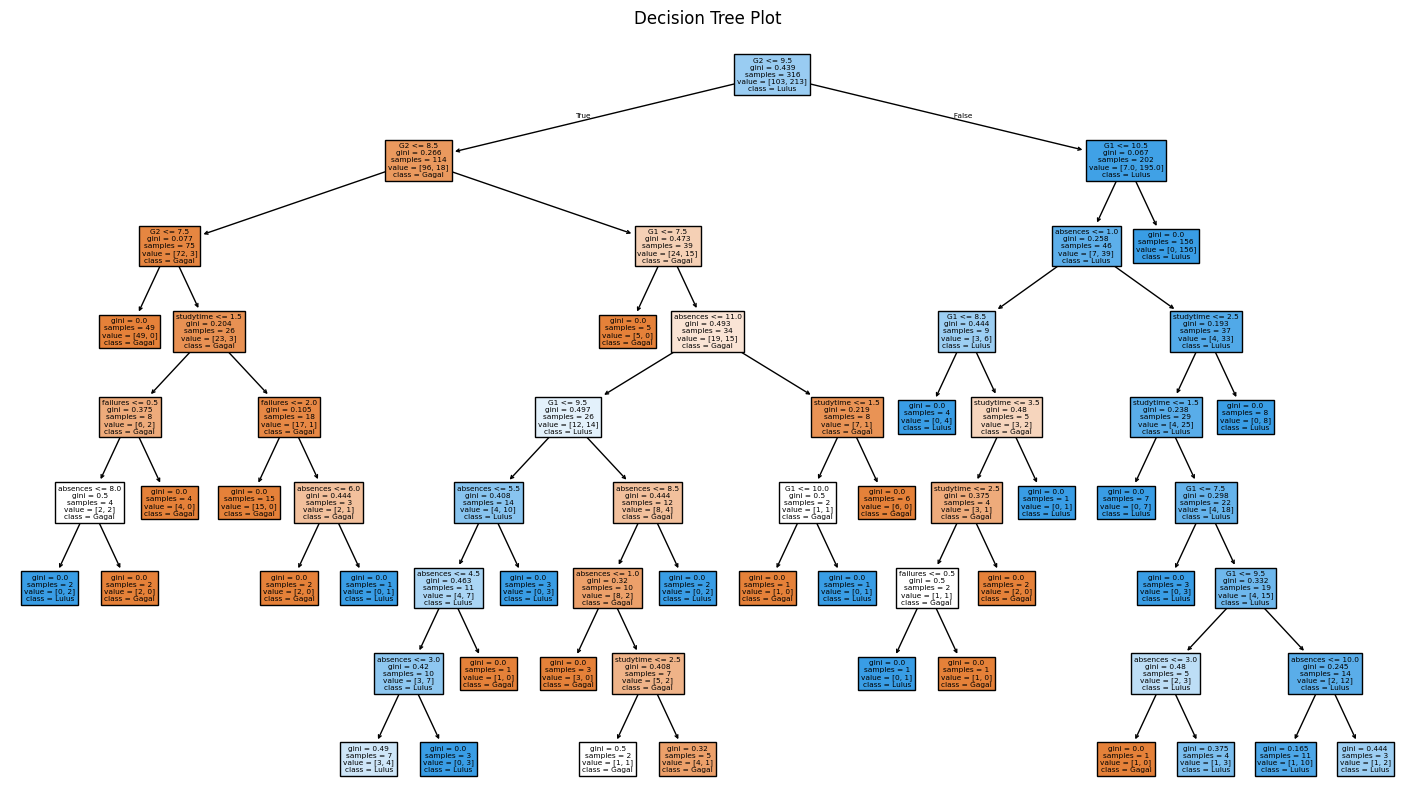

In [7]:
dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

# Output Teks (Akurasi & Report)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# 1. Visualisasi Diagram Pohon
plt.figure(figsize=(18, 10))
plot_tree(dt, feature_names=X_train.columns, class_names=['Gagal', 'Lulus'], filled=True)
plt.title("Decision Tree Plot")
plt.show()

Untuk model Decision Tree, diperoleh akurasi sebesar 89,87%, yang berarti hampir 90% data uji berhasil diprediksi dengan benar oleh model. Nilai precision, recall, dan f1-score untuk kelas 0 sebesar 85%, sedangkan untuk kelas 1 mencapai 92%, sehingga dapat disimpulkan bahwa model lebih baik dalam mengenali data pada kelas 1. Dari gambar pohon keputusan terlihat bahwa model menggunakan beberapa atribut seperti G2, G1, absences, failures, dan studytime untuk menentukan hasil klasifikasi. Setiap percabangan pada pohon membantu model dalam mengambil keputusan berdasarkan kondisi tertentu hingga diperoleh hasil akhir. Secara keseluruhan, Decision Tree menunjukkan kinerja yang sangat baik dalam mengklasifikasikan data dan menghasilkan akurasi yang sedikit lebih tinggi dibandingkan model Naive Bayes.

SVM

SVM berusaha memaksimalkan jarak antara batas pemisah dan data terdekat sehingga menghasilkan model yang memiliki kemampuan prediksi yang baik. Algoritma ini efektif digunakan pada data yang memiliki banyak fitur dan pola yang kompleks.

=== SUPPORT VECTOR MACHINE (SVM) ===
Accuracy: 0.8860759493670886
              precision    recall  f1-score   support

           0       0.80      0.89      0.84        27
           1       0.94      0.88      0.91        52

    accuracy                           0.89        79
   macro avg       0.87      0.89      0.88        79
weighted avg       0.89      0.89      0.89        79



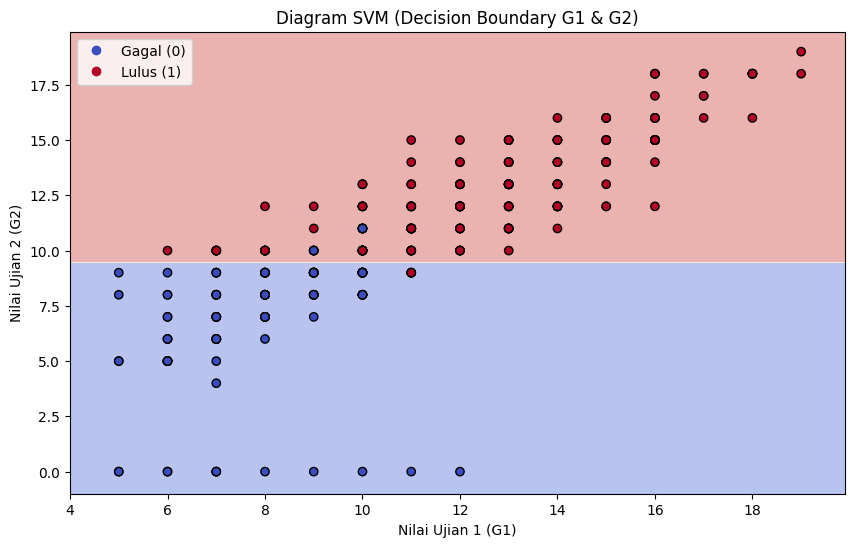

In [8]:

print("=== SUPPORT VECTOR MACHINE (SVM) ===")
# ==========================================
# 3. MODEL SVM
# ==========================================
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

# Output Teks (Akurasi & Report)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# 1. Visualisasi Diagram SVM (Garis Batas / Decision Boundary)
# (Kita pakai 2 fitur G1 & G2 agar bisa digambar dalam grafik 2D)
X_2d = X_train[['G1', 'G2']]
svm_2d = SVC(kernel='linear').fit(X_2d, y_train)

x_min, x_max = X_2d['G1'].min() - 1, X_2d['G1'].max() + 1
y_min, y_max = X_2d['G2'].min() - 1, X_2d['G2'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
scatter = plt.scatter(X_train['G1'], X_train['G2'], c=y_train, cmap='coolwarm', edgecolors='k')
plt.xlabel('Nilai Ujian 1 (G1)')
plt.ylabel('Nilai Ujian 2 (G2)')
plt.title('Diagram SVM (Decision Boundary G1 & G2)')
handles, _ = scatter.legend_elements()
plt.legend(handles, ['Gagal (0)', 'Lulus (1)'])
plt.show()


Berlanjut dari hasil model Support Vector Machine (SVM) memperoleh akurasi sebesar yaitu 88,61%, yang berarti ada sekitar 89% data itu berhasil diprediksi dengan benar. Pada grafik terlihat bahwa SVM mampu memisahkan data Gagal (0) dan Lulus (1) dengan cukup jelas bisa dilihat berdasarkan nilai G1 dan G2 area berwarna biru menunjukkan prediksi gagal, sedangkan area berwarna merah menunjukkan prediksi lulus. Selain itu, nilai precision, recall, dan f1-score yang berada pada kisaran 80%–94% menunjukkan bahwa model memiliki kemampuan yang baik dalam melakukan klasifikasi secara keseluruhan pada model SVM memberikan hasil yang cukup baik dengan tingkat akurasi yang tinggi dan mampu memisahkan data lulus dan gagal dengan jelas.

SVR

Support Vector Regression (SVR) adalah pengembangan dari Support Vector Machine (SVM) yang digunakan untuk tugas regresi atau prediksi nilai numerik. SVR bekerja dengan mencari garis regresi terbaik yang mampu memprediksi nilai target dengan tingkat kesalahan seminimal mungkin.

=== SUPPORT VECTOR REGRESSION (SVR) ===
Accuracy (Converted): 0.8481012658227848
Mean Squared Error (MSE): 4.089711577517274

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.96      0.81        27
           1       0.98      0.79      0.87        52

    accuracy                           0.85        79
   macro avg       0.84      0.88      0.84        79
weighted avg       0.88      0.85      0.85        79



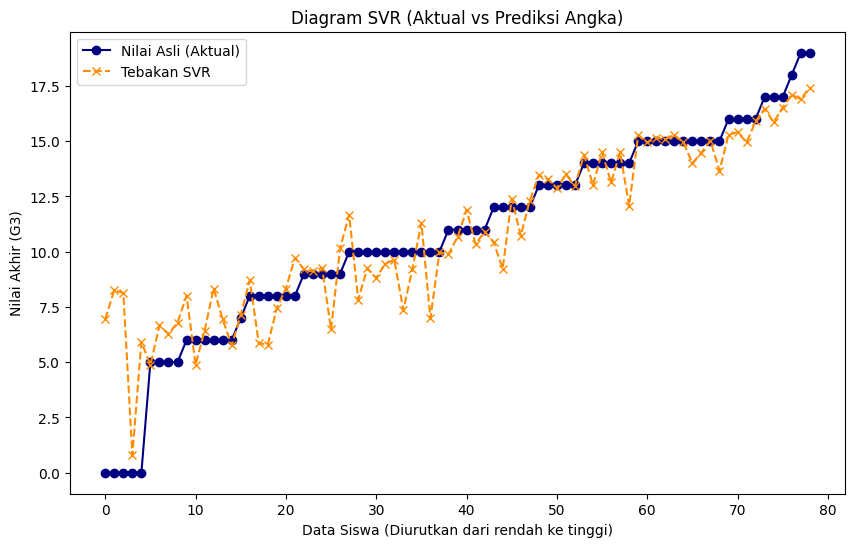

In [9]:
print("=== SUPPORT VECTOR REGRESSION (SVR) ===")
# ==========================================
# 4. MODEL SVR
# ==========================================
# Khusus SVR, targetnya harus nilai angka asli (bukan 1/0)
y_reg = df['G3'] 
_, _, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train_reg)

# SVR menebak angka asli
y_pred_svr_num = svr_model.predict(X_test)

# Kita ubah hasil tebakan angkanya jadi kelas Lulus(1)/Gagal(0) khusus untuk evaluasi matriks
y_pred_svr_class = np.where(y_pred_svr_num >= 10, 1, 0)

# Output Teks (Akurasi, MSE, & Report)
print("Accuracy (Converted):", accuracy_score(y_test, y_pred_svr_class))
print("Mean Squared Error (MSE):", mean_squared_error(y_test_reg, y_pred_svr_num))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svr_class))

# 1. Visualisasi Kurva Regresi (Nilai Asli vs Tebakan SVR)
plt.figure(figsize=(10, 6))
sorted_indices = np.argsort(y_test_reg.values)
plt.plot(y_test_reg.values[sorted_indices], label='Nilai Asli (Aktual)', color='navy', marker='o')
plt.plot(y_pred_svr_num[sorted_indices], label='Tebakan SVR', color='darkorange', linestyle='--', marker='x')
plt.ylabel('Nilai Akhir (G3)')
plt.xlabel('Data Siswa (Diurutkan dari rendah ke tinggi)')
plt.title('Diagram SVR (Aktual vs Prediksi Angka)')
plt.legend()
plt.show()

Pada model Support Vector Regression (SVR) itu memperoleh akurasi sebesar 84,81% dengan nilai Mean Squared Error (MSE) sebesar 4,09 bisa di lihat ada grafik terlihat bahwa garis prediksi SVR (garis oranye) cukup mengikuti pola nilai asli (garis biru), meskipun pada beberapa titik masih terdapat selisih antara nilai prediksi dan nilai sebenarnya. Hal ini menunjukkan bahwa model mampu memperkirakan nilai akhir siswa dengan cukup baik, tetapi belum sepenuhnya tepat pada semua data. Nilai MSE sebesar 4,09 menunjukkan bahwa rata-rata kesalahan prediksi model masih relatif kecil. Secara keseluruhan, model SVR memiliki performa yang cukup baik dalam memprediksi nilai akhir siswa berdasarkan data yang digunakan

K MEANS

K-Means adalah algoritma clustering yang digunakan untuk mengelompokkan data ke dalam sejumlah cluster berdasarkan kemiripan karakteristiknya. Algoritma ini bekerja dengan menentukan titik pusat cluster (centroid), kemudian mengelompokkan setiap data ke centroid terdekat. Proses tersebut diulang hingga posisi centroid stabil dan tidak mengalami perubahan yang signifikan. K-Means sering digunakan untuk menemukan pola atau segmentasi data tanpa memerlukan label kelas.

DATA MINING: MENENTUKAN JUMLAH K (ELBOW & DENDROGRAM) 

--- 4. DATA MINING: MENCARI NILAI K OPTIMAL ---


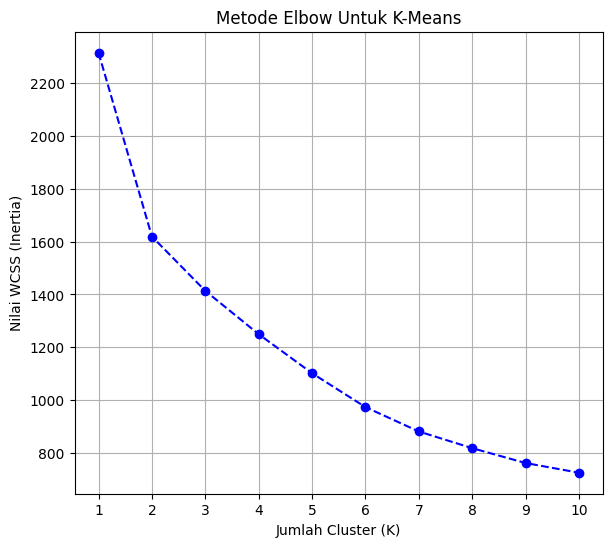

In [10]:
print("--- 4. DATA MINING: MENCARI NILAI K OPTIMAL ---")

plt.figure(figsize=(15, 6))

# A. Visualisasi Elbow Method untuk K-Means
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(df_scaled)
    wcss.append(kmeans_test.inertia_)

plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Metode Elbow Untuk K-Means')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Nilai WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)

Berdasarkan grafik Elbow Method, nilai WCSS terus menurun ketika jumlah cluster ditambah. Namun, penurunan yang paling besar terjadi sampai K=3, kemudian grafik mulai melandai. Oleh karena itu, K=3 dipilih sebagai jumlah cluster terbaik karena sudah mampu mengelompokkan data dengan baik tanpa menambah cluster secara berlebihan.

Hierarchical

Hierarchical Clustering adalah algoritma clustering yang mengelompokkan data secara bertahap berdasarkan tingkat kemiripannya hingga membentuk struktur hierarki berupa dendrogram. Algoritma ini tidak memerlukan penentuan jumlah cluster di awal dan memungkinkan pengguna melihat hubungan antar data pada berbagai tingkat pengelompokan. Hierarchical Clustering sering digunakan untuk menganalisis pola dan struktur data secara lebih mendalam.

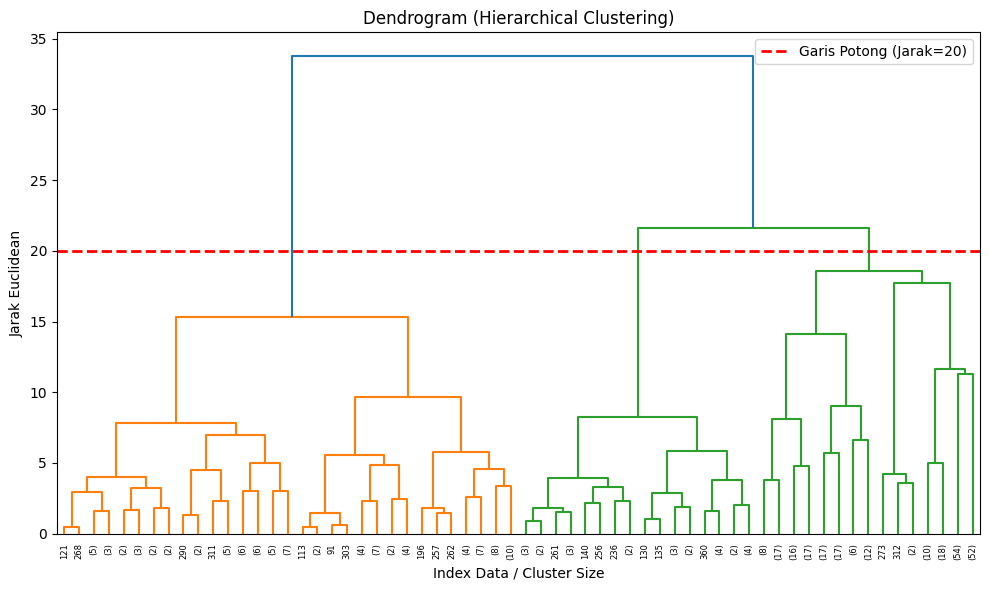

In [11]:
plt.figure(figsize=(10, 6)) # Disesuaikan sedikit agar fokus ke dendrogram
plt.title("Dendrogram (Hierarchical Clustering)")
linkage_data = linkage(df_scaled, method='ward', metric='euclidean')
dendrogram(linkage_data, truncate_mode='level', p=5)
plt.xlabel("Index Data / Cluster Size")
plt.ylabel("Jarak Euclidean")

# --- MENAMBAHKAN GARIS PEMOTONG ---
# CATATAN: Nilai y=20 di bawah ini adalah perkiraan (estimasi). 
# Setelah kamu merun kodenya, lihat grafiknya. Jika garis merah tidak pas 
# memotong 4 cabang vertikal, naikkan atau turunkan angka 20 ini.
batas_potong = 20 
plt.axhline(y=batas_potong, color='r', linestyle='--', linewidth=2, label=f'Garis Potong (Jarak={batas_potong})')
plt.legend()

plt.tight_layout()
plt.show()

Berdasarkan dendrogram yang dihasilkan, garis potong ditetapkan pada jarak Euclidean sebesar 20. Garis tersebut memotong tiga cabang utama sehingga diperoleh 3 cluster sebagai jumlah cluster yang optimal. Pemilihan K = 3 dilakukan karena mampu memisahkan data ke dalam kelompok yang memiliki tingkat kemiripan tinggi di dalam cluster dan perbedaan yang cukup jelas antar cluster.

In [12]:
k_optimal = 3
print(f"\nBerdasarkan grafik di atas, kita menetapkan nilai K = {k_optimal} untuk pemodelan.\n")


Berdasarkan grafik di atas, kita menetapkan nilai K = 3 untuk pemodelan.



PEMODELAN CLUSTERING PADA KMEANS HIERCHICAL

In [13]:
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(df_scaled)

# Hierarchical
hierarchical_model = AgglomerativeClustering(n_clusters=k_optimal, metric='euclidean', linkage='ward')
hierarchical_labels = hierarchical_model.fit_predict(df_scaled)

# Menyimpan hasil label ke dataframe asli yang sudah bersih
df_clean['Cluster_KMeans'] = kmeans_labels
df_clean['Cluster_Hierarchical'] = hierarchical_labels
print("Model K-Means dan Hierarchical Clustering berhasil dibuat.\n")

Model K-Means dan Hierarchical Clustering berhasil dibuat.



5. Evaluation & Visualization

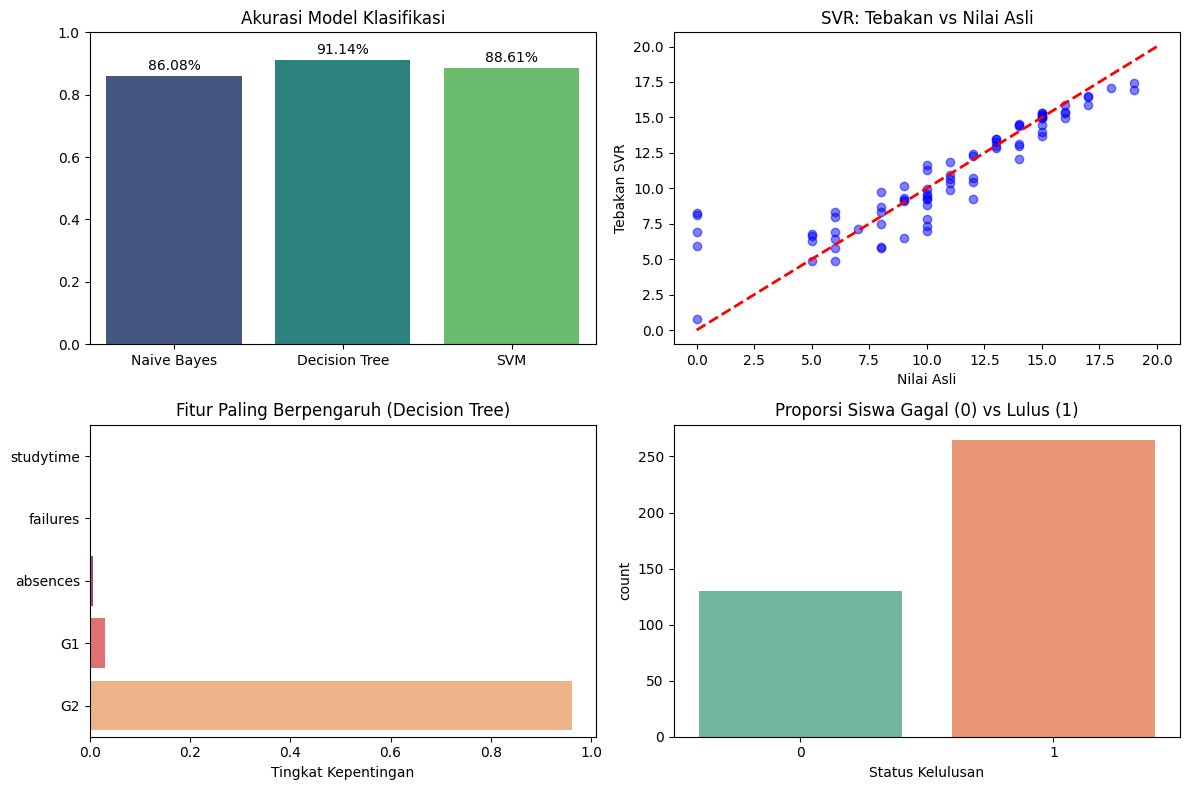

Tahap Evaluasi Selesai!


In [14]:
# Hitung Akurasi
acc_nb = accuracy_score(y_test, nb_model.predict(X_test))
acc_dt = accuracy_score(y_test, dt_model.predict(X_test))
acc_svm = accuracy_score(y_test, svm_model.predict(X_test))

# ================= BIKIN GRAFIK =================
plt.figure(figsize=(12, 8))

# 1. Grafik Kiri Atas: Akurasi
plt.subplot(2, 2, 1) 
sns.barplot(x=['Naive Bayes', 'Decision Tree', 'SVM'], y=[acc_nb, acc_dt, acc_svm], palette='viridis')
plt.title('Akurasi Model Klasifikasi')
plt.ylim(0, 1) 
for i, v in enumerate([acc_nb, acc_dt, acc_svm]):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center')

# 2. Grafik Kanan Atas: SVR
plt.subplot(2, 2, 2) 
plt.scatter(y_test_reg, svr_model.predict(X_test), color='blue', alpha=0.5)
plt.plot([0, 20], [0, 20], 'r--', lw=2) 
plt.title('SVR: Tebakan vs Nilai Asli')
plt.xlabel('Nilai Asli')
plt.ylabel('Tebakan SVR')

# 3. Grafik Kiri Bawah: Fitur Penting Decision Tree
plt.subplot(2, 2, 3) 
sns.barplot(x=dt_model.feature_importances_, y=features, palette='magma')
plt.title('Fitur Paling Berpengaruh (Decision Tree)')
plt.xlabel('Tingkat Kepentingan')

# 4. Grafik Kanan Bawah: Data Lulus vs Gagal
plt.subplot(2, 2, 4) 
sns.countplot(x=y_class, palette='Set2')
plt.title('Proporsi Siswa Gagal (0) vs Lulus (1)')
plt.xlabel('Status Kelulusan')

plt.tight_layout()
plt.show()

print("Tahap Evaluasi Selesai!")

Dari hasil tersebut, Decision Tree menjadi model terbaik karena memiliki akurasi paling tinggi yaitu 89,87%, diikuti oleh SVM (88,61%), Naive Bayes (86,08%), dan SVR (84,81%). Hal ini menunjukkan bahwa Decision Tree paling mampu mengenali pola pada dataset siswa yang digunakan sehingga menghasilkan prediksi yang lebih akurat dibandingkan model lainnya.

Confusion matrix

--- PROSES EVALUASI & VISUALISASI ---


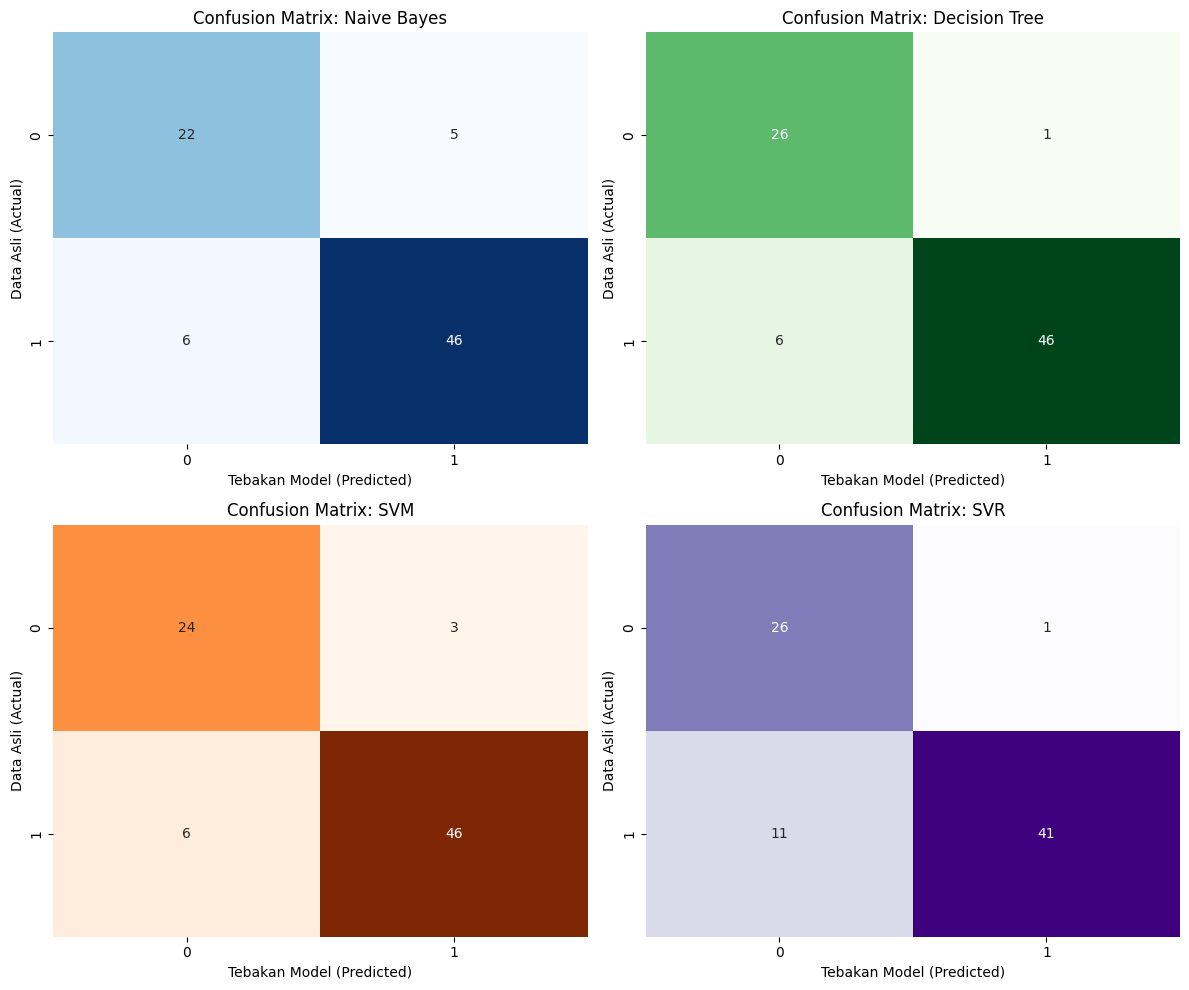

Selesai! Gambar Confusion Matrix berhasil ditampilkan.


In [15]:
print("--- PROSES EVALUASI & VISUALISASI ---")

# Khusus SVR: Kita ubah tebakan angka jadi kelas (Lulus/Gagal) biar bisa dibikin matriks
# Kalau tebakan >= 10 kita anggap Lulus (1), di bawah 10 anggap Gagal (0)
svr_pred_class = np.where(svr_model.predict(X_test) >= 10, 1, 0)

# Menyiapkan 'kanvas' gambar ukuran 12x10, dibagi jadi 2 baris dan 2 kolom
plt.figure(figsize=(12, 10))

# 1. Matriks Naive Bayes (Kiri Atas)
plt.subplot(2, 2, 1)
cm_nb = confusion_matrix(y_test, nb_model.predict(X_test))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Naive Bayes')
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Data Asli (Actual)')

# 2. Matriks Decision Tree (Kanan Atas)
plt.subplot(2, 2, 2)
cm_dt = confusion_matrix(y_test, dt_model.predict(X_test))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix: Decision Tree')
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Data Asli (Actual)')

# 3. Matriks SVM (Kiri Bawah)
plt.subplot(2, 2, 3)
cm_svm = confusion_matrix(y_test, svm_model.predict(X_test))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Confusion Matrix: SVM')
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Data Asli (Actual)')

# 4. Matriks SVR (Kanan Bawah)
plt.subplot(2, 2, 4)
cm_svr = confusion_matrix(y_test, svr_pred_class)
sns.heatmap(cm_svr, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix: SVR')
plt.xlabel('Tebakan Model (Predicted)')
plt.ylabel('Data Asli (Actual)')

# Rapikan tata letak biar tulisan nggak saling tabrakan
plt.tight_layout()
plt.show()

print("Selesai! Gambar Confusion Matrix berhasil ditampilkan.")

Berdasarkan confusion matrix, terlihat bahwa sebagian besar data berhasil diklasifikasikan dengan benar oleh setiap model. Decision Tree menghasilkan jumlah prediksi benar terbanyak dibandingkan model lainnya, sehingga memperoleh akurasi tertinggi sebesar 89,87%. Sementara itu, Naive Bayes dan SVM juga menunjukkan performa yang baik dengan jumlah kesalahan klasifikasi yang relatif sedikit.

EVALUASI K MEANS DAN HIERARCHICAL

Scatter Plot K-means

In [16]:


# PCA 3D
pca = PCA(n_components=3)
data_pca = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    data_pca,
    columns=['PC1', 'PC2', 'PC3']
)

df_pca['Cluster'] = kmeans_labels.astype(str)

fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title=f'K-Means Clustering PCA 3D (K={k_optimal})'
)

fig.update_traces(marker=dict(size=4))
fig.show()

Berdasarkan hasil K-Means Clustering dengan nilai K = 3, data berhasil dikelompokkan menjadi tiga cluster yang ditunjukkan oleh warna biru, merah, dan hijau. Visualisasi PCA 3D menunjukkan bahwa sebagian besar data dalam satu cluster memiliki karakteristik yang mirip dan terletak berdekatan, sedangkan antar cluster terlihat cukup terpisah. Hal ini menunjukkan bahwa proses clustering berhasil membagi data ke dalam tiga kelompok utama berdasarkan kemiripan karakteristik data.

Scatter Plot Hierarchical

In [17]:
# ==========================
# HITUNG SILHOUETTE SCORE
# ==========================
sil_hierarchical = silhouette_score(
    df_scaled,
    hierarchical_labels
)

print(f"Silhouette Score Hierarchical : {sil_hierarchical:.4f}")

# ==========================
# PCA 3 DIMENSI
# ==========================
pca = PCA(n_components=3)
data_pca = pca.fit_transform(df_scaled)

# ==========================
# DATAFRAME UNTUK PLOTLY
# ==========================
df_pca = pd.DataFrame(
    data_pca,
    columns=['PC1', 'PC2', 'PC3']
)

df_pca['Cluster'] = hierarchical_labels.astype(str)

# ==========================
# VISUALISASI 3D INTERAKTIF
# ==========================
fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title=f'Hierarchical Clustering PCA 3D (K={k_optimal})<br>Silhouette Score: {sil_hierarchical:.3f}'
)

fig.update_traces(
    marker=dict(size=5)
)

fig.update_layout(
    scene=dict(
        xaxis_title='Principal Component 1',
        yaxis_title='Principal Component 2',
        zaxis_title='Principal Component 3'
    ),
    width=900,
    height=700
)

fig.show()

Silhouette Score Hierarchical : 0.2054


Pada hasil Hierarchical Clustering, data terbagi menjadi 3 kelompok yang ditunjukkan dengan warna biru, merah, dan hijau. Data yang berada dalam warna yang sama memiliki karakteristik yang mirip. Cluster biru berisi anggota paling banyak, cluster merah terlihat cukup terpisah dari kelompok lain, sedangkan cluster hijau berisi anggota yang lebih sedikit. Hal ini menunjukkan bahwa metode Hierarchical Clustering berhasil mengelompokkan data berdasarkan kemiripan karakteristiknya.

Menghitung rata rata cluster

In [18]:
# 1. Menghitung rata-rata untuk semua kolom numerik di setiap cluster
tabel_summary = df_clean.groupby('Cluster_KMeans')[['studytime', 'freetime', 'absences', 'G1', 'G2', 'G3']].mean()

# 2. Membulatkan hasilnya menjadi 2 angka di belakang koma agar rapi
print("--- TABEL RATA-RATA KARAKTERISTIK CLUSTER ---")
display(tabel_summary.round(2))

--- TABEL RATA-RATA KARAKTERISTIK CLUSTER ---


,studytime,freetime,absences,G1,G2,G3
Cluster_KMeans,,,,,,
0,1.89,3.31,3.09,6.97,5.27,2.89
1,1.96,3.15,8.19,9.61,9.82,10.00
2,2.20,3.30,3.93,14.45,14.42,14.61


Penjelasan Cluster

CLUSTER 0 sering bolos
- cluster 0 absences = 24.24 (Sangat Tinggi), studytime = 1.73 (Paling Rendah), G3 = 9.21.
- pada kolom absences, angka 24.24 adalah yang paling besar di antara semua kelompok yang berarti, rata-rata murid di sini bolos sampai 24 kali dalam satu semester
- Hasilnya adalah nilai ujian akhir (G3) mereka pas-pasan banget, yaitu 9.21.

CLUSTER 1 Ambis (juara)
- Kelompok ini punya angka studytime tertinggi (2.19), yang berarti mereka paling rajin belajar dibanding kelompok lain.
- Nilai ujian mereka dari awal (G1 = 14.67) sampai ujian akhir (G3 = 14.89) konsisten paling tinggi dan stabil naik. Mereka adalah kumpulan anak-anak berprestasi.
- Angka bolosnya juga paling kecil hanya 3 kali

CLUSTER 2   Butuh Bimbingan ekstra 
- Kelompok ini punya angka unik. Lihat kolom absences, nilainya cuma 2.80 (paling kecil). Artinya, mereka adalah anak-anak yang paling rajin masuk sekolah dan jarang absen.
- meskipun sering hadir nilai mereka (G1) sudah kecil banget terus G3 malah makin anjlok
- Walaupun mereka rajin hadir di kelas, mereka memiliki kesulitan besar dalam memahami pelajaran sehingga nilainya tertinggal jauh di bawah teman-temannya

CLUSTER 3 Kelompok Murid "Rata-Rata" (Normal)
- studytime = 2.04, absences = 4.63, G3 = 10.23.
- Angka-angka di kelompok ini berada di posisi "tengah-tengah". Waktu belajarnya standar (2.04), jumlah absennya normal di angka 4 kali, dan waktu luangnya juga seimbang.
- Nilai akhir ujian mereka (G3) berada di angka 10.23. Tidak terlalu pintar seperti Cluster 1, tapi tidak anjlok seperti Cluster 2. Ini adalah profil murid reguler pada umumnya

APRIORI KELOMPOK

In [19]:
from mlxtend.frequent_patterns import apriori, association_rules

print("=== TUGAS KELOMPOK: INTEGRASI APRIORI (BAB 1 - BAB 5) ===\n")

# =========================================================================
# TAHAP 1: SIMULASI PENGGABUNGAN DATASET (GILANG, IRA, RION, ROSA, KHAISAN)
# =========================================================================
# Catatan: Di kodingan asli, kelompok lu tinggal gabungkan dataframe pakai pd.concat() atau pd.merge()
# Di bawah ini adalah replika struktur data gabungan berdasarkan flowchart kelompok lu

np.random.seed(42)
n_samples = 1000

data_kelompok = pd.DataFrame({
    # 1. Dataset Gilang (Bab 1: Kebiasaan Mikro)
    'sosmed_hours': np.random.uniform(1.0, 8.0, n_samples),
    'sleep_hours': np.random.uniform(4.0, 9.0, n_samples),

    # 2. Dataset Ira (Bab 2: Kualitas SDM)
    'study_time': np.random.randint(1, 5, n_samples),
    'g3_score': np.random.uniform(2.0, 4.0, n_samples),

    # 3. Dataset Rion (Bab 3: Pasar Aplikasi)
    'app_growth': np.random.uniform(-10, 50, n_samples),

    # 4. Dataset Rosa (Bab 4: Pasar Gaming Global)
    'gaming_spending': np.random.uniform(0, 500, n_samples),

    # 5. Dataset Khaisan (Bab 5: Kekuatan Paspor)
    'passport_rank': np.random.randint(1, 190, n_samples)
})


# =========================================================================
# TAHAP 2: BINNING & DISKRETISASI (MENGUBAH ANGKA MENJADI KATEGORI)
# =========================================================================
df_kategori = pd.DataFrame()

# ➔ Binning Data Gilang (Bab 1)
df_kategori['Sosmed_Tinggi'] = data_kelompok['sosmed_hours'] > 4.5
df_kategori['Tidur_Kurang'] = data_kelompok['sleep_hours'] < 6.5

# ➔ Binning Data Ira (Bab 2)
df_kategori['Belajar_Tekun'] = data_kelompok['study_time'] >= 3
df_kategori['Nilai_Unggul'] = data_kelompok['g3_score'] > 3.4

# ➔ Binning Data Rion (Bab 3)
df_kategori['App_Growth_Pesat'] = data_kelompok['app_growth'] > 20

# ➔ Binning Data Rosa (Bab 4)
df_kategori['Gamer_Sultan'] = data_kelompok['gaming_spending'] > 250

# ➔ Binning Data Khaisan (Bab 5)
df_kategori['Paspor_Kuat'] = data_kelompok['passport_rank'] < 50

print("➔ Langkah 1: Berhasil mengubah data kontinu kelompok menjadi format boolean (True/False)!")


# =========================================================================
# TAHAP 3: EKSEKUSI ALGORITMA APRIORI
# =========================================================================
# Mencari kombinasi itemset yang sering muncul berbarengan di dataset
# min_support = 0.05 artinya kombinasi tersebut minimal muncul di 5% dari total data
frequent_itemsets = apriori(df_kategori, min_support=0.05, use_colnames=True)

print(f"➔ Langkah 2: Berhasil menemukan {len(frequent_itemsets)} pola itemset yang sering muncul.")


# =========================================================================
# TAHAP 4: GENERASI ATURAN ASOSIASI (ASSOCIATION RULES)
# =========================================================================
# Membongkar aturan "Jika-Maka" antar-Bab
# Kita gunakan metrik 'lift' dengan batas minimal 1.05 untuk mencari hubungan kausalitas yang kuat
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.05)

# Menyortir aturan dari yang memiliki nilai keyakinan (Confidence) tertinggi
rules = rules.sort_values(by='confidence', ascending=False).reset_index(drop=True)

print("➔ Langkah 3: Aturan asosiasi integrasi antar-Bab berhasil terbentuk!\n")


# =========================================================================
# TAHAP 5: FILTERING ATURAN LINTAS DATASET UNTUK LAPORAN
# =========================================================================
# Menampilkan 10 aturan terbaik yang siap dimasukkan ke dalam Bab 5 / Kesimpulan laporan kelompok
Tabel_Apriori_Kelompok = rules[[
    'antecedents', 'consequents', 'support', 'confidence', 'lift'
]].head(70)

# Merapikan tampilan nama kolom untuk output laporan
Tabel_Apriori_Kelompok.columns = ['Jika (Antecedents)', 'Maka (Consequents)', 'Support', 'Confidence', 'Lift Score']

display(Tabel_Apriori_Kelompok)

=== TUGAS KELOMPOK: INTEGRASI APRIORI (BAB 1 - BAB 5) ===

➔ Langkah 1: Berhasil mengubah data kontinu kelompok menjadi format boolean (True/False)!
➔ Langkah 2: Berhasil menemukan 63 pola itemset yang sering muncul.
➔ Langkah 3: Aturan asosiasi integrasi antar-Bab berhasil terbentuk!



,Jika (Antecedents),Maka (Consequents),Support,Confidence,Lift Score
0,"frozenset({Paspor_Kuat, App_Growth_Pesat})",frozenset({Sosmed_Tinggi}),0.071,0.606838,1.221001
1,"frozenset({Sosmed_Tinggi, Paspor_Kuat})",frozenset({Belajar_Tekun}),0.083,0.592857,1.162465
2,"frozenset({Belajar_Tekun, App_Growth_Pesat, Ga...",frozenset({Sosmed_Tinggi}),0.065,0.570175,1.147234
3,"frozenset({Belajar_Tekun, Paspor_Kuat})",frozenset({Sosmed_Tinggi}),0.083,0.568493,1.143849
4,"frozenset({Paspor_Kuat, Tidur_Kurang})",frozenset({Belajar_Tekun}),0.072,0.558140,1.094391
5,"frozenset({Nilai_Unggul, Tidur_Kurang})",frozenset({Belajar_Tekun}),0.082,0.554054,1.086380
6,"frozenset({Belajar_Tekun, App_Growth_Pesat})",frozenset({Sosmed_Tinggi}),0.132,0.550000,1.106640
7,"frozenset({Sosmed_Tinggi, Nilai_Unggul})",frozenset({Belajar_Tekun}),0.084,0.549020,1.076509
8,frozenset({Paspor_Kuat}),frozenset({Belajar_Tekun}),0.146,0.546816,1.072189
9,"frozenset({Paspor_Kuat, Gamer_Sultan})",frozenset({Tidur_Kurang}),0.066,0.540984,1.117735


Dari hasil Apriori tersebut, aturan yang paling menarik dapat dilihat dari nilai confidence dan lift yang paling tinggi. Semakin tinggi nilai confidence, semakin besar kemungkinan konsekuen terjadi ketika jika terpenuhi. Sedangkan nilai lift yang lebih besar dari 1 menunjukkan adanya hubungan positif antar item.

Beberapa aturan yang dapat dijelaskan adalah:
1. {App_Growth_Pesat, Paspor_Kuat} → {Sosmed_Tinggi}

Memiliki support 0,071, confidence 0,607, dan lift 1,221. Artinya, sekitar 7,1% data memiliki ketiga karakteristik tersebut secara bersamaan. Jika suatu data memiliki pertumbuhan aplikasi yang pesat dan paspor yang kuat, maka terdapat peluang sebesar 60,7% juga memiliki penggunaan media sosial yang tinggi. Nilai lift 1,221 menunjukkan hubungan positif yang cukup kuat.

2. {Sosmed_Tinggi, Paspor_Kuat} → {Belajar_Tekun}

Memiliki confidence 59,3% dan lift 1,162. Hal ini menunjukkan bahwa individu dengan penggunaan media sosial tinggi dan paspor kuat cenderung memiliki kebiasaan belajar yang tekun dibandingkan rata-rata data.

3. {Belajar_Tekun, Paspor_Kuat} → {Sosmed_Tinggi}

Memiliki confidence 56,8% dan lift 1,144. Artinya, data yang memiliki kebiasaan belajar tekun dan paspor kuat memiliki kemungkinan cukup besar untuk juga termasuk kategori penggunaan media sosial tinggi.

4. {Tidur_Kurang, Paspor_Kuat} → {Belajar_Tekun}

Memiliki confidence 55,8%. Ini menunjukkan bahwa lebih dari setengah data yang memiliki tidur kurang dan paspor kuat juga termasuk kategori belajar tekun.

5. {Belajar_Tekun, App_Growth_Pesat} → {Sosmed_Tinggi}

Memiliki support 13,2% dan confidence 55%. Artinya, individu yang belajar tekun dan berada pada lingkungan pertumbuhan aplikasi yang pesat cenderung memiliki aktivitas media sosial yang tinggi.

KESIMPULAN

Berdasarkan hasil Apriori, pola yang paling sering muncul menunjukkan bahwa Sosmed_Tinggi menjadi konsekuen yang paling dominan dalam berbagai aturan asosiasi. Selain itu, kombinasi variabel App_Growth_Pesat, Paspor_Kuat, dan Belajar_Tekun memiliki hubungan positif terhadap kemunculan Sosmed_Tinggi. Seluruh aturan yang ditampilkan memiliki nilai lift lebih dari 1, sehingga hubungan antar variabel dapat dianggap memiliki korelasi positif dan bukan terjadi secara kebetulan. Dengan demikian, terdapat keterkaitan antara kebiasaan penggunaan media sosial, aktivitas belajar, pertumbuhan aplikasi, kekuatan paspor, serta beberapa karakteristik lainnya dalam dataset gabungan kelompok.